### Formatting caliban data to be inputted into tARHMM

In [1]:
import pickle
import numpy as np

import zipfile
from io import BytesIO
import tifffile

In [2]:
with open("/gladstone/engelhardt/lab/MarsonLabIncucyteData/SnakemakeRuns/Caliban_600xy/output/B3/Caliban/B3_div.pkl", "rb") as f:
    division_data = pickle.load(f)

/tmp/ipykernel_2179347/2158595522.py:2: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  division_data = pickle.load(f)


In [3]:
division_data

,parent,daughter_1,daughter_2,frame
0,2,336,337,9
1,4,511,513,57
2,5,1103,1108,228
3,7,881,883,165
4,9,309,316,5
...,...,...,...,...
323,1054,1157,1158,241
324,1058,1092,1096,226
325,1089,1152,1154,239
326,1164,1168,1170,243


In [4]:
caliban_tracks_path = "/gladstone/engelhardt/lab/MarsonLabIncucyteData/SnakemakeRuns/Caliban_600xy/output/B3/Caliban/deepcell_tracks.zip"

In [5]:
# load caliban tracks
dcl_ob = zipfile.ZipFile(caliban_tracks_path, 'r')
file_bytes = dcl_ob.read("y.ome.tiff")
with BytesIO(file_bytes) as b:
    caliban_tracks = tifffile.imread(b) # T x H x W

In [7]:
caliban_tracks.shape

(250, 600, 600)

In [18]:
print(np.unique(caliban_tracks[caliban_tracks > 0]))
print(len(np.unique(caliban_tracks[caliban_tracks > 0])))

[   1    2    3 ... 1198 1199 1200]
1200


In [16]:
np.unique(np.where(caliban_tracks == 2)[0])

array([0, 1, 2, 5, 7, 8])

In [21]:
division_data, caliban_tracks

(     parent  daughter_1  daughter_2  frame
 0         2         336         337      9
 1         4         511         513     57
 2         5        1103        1108    228
 3         7         881         883    165
 4         9         309         316      5
 ..      ...         ...         ...    ...
 323    1054        1157        1158    241
 324    1058        1092        1096    226
 325    1089        1152        1154    239
 326    1164        1168        1170    243
 327    1180        1188        1193    247
 
 [328 rows x 4 columns],
 array([[[2, 2, 2, ..., 0, 0, 0],
         [2, 2, 2, ..., 0, 0, 0],
         [2, 2, 2, ..., 0, 0, 0],
         ...,
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0]],
 
        [[0, 0, 2, ..., 0, 0, 0],
         [2, 2, 2, ..., 0, 0, 0],
         [2, 2, 2, ..., 0, 0, 0],
         ...,
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0]],
 
   

In [88]:
# --- Convert division_data + caliban_tracks into tARHMM arrays ---

data = {}

# Extract relevant info from division_data and caliban_tracks to build:
T = caliban_tracks.shape[0]

all_cell_ids = np.unique(caliban_tracks[caliban_tracks > 0])
all_cell_ids.sort()
num_cells = len(all_cell_ids)
id_to_col = {int(cid): i for i, cid in enumerate(all_cell_ids)}

print(f"T={T}, num_cells={num_cells}")

# Initialize all masks
active_mask = np.zeros((T, num_cells), dtype=bool)
is_division_mask = np.zeros((T, num_cells), dtype=bool)
is_new_root_mask = np.zeros((T, num_cells), dtype=bool)
parent_indices = np.zeros((T, num_cells), dtype=np.int32)

# Make active_mask from caliban_tracks
for t in range(T):
    caliban_frame = caliban_tracks[t]
    frame_ids = np.unique(caliban_frame[caliban_frame > 0])
    for cid in frame_ids:
        active_mask[t, id_to_col[int(cid)]] = True

# 3. Parse division_data: build daughter->parent map and ensure that parents are deactivated from the division frame onward
daughter_to_parent = {}  # daughter_cell_id -> (parent_cell_id, division_frame)

for _, row in division_data.iterrows():
    parent_id = int(row["parent"])
    d1_id = int(row["daughter_1"])
    d2_id = int(row["daughter_2"])
    div_frame = int(row["frame"])

    daughter_to_parent[d1_id] = (parent_id, div_frame)
    daughter_to_parent[d2_id] = (parent_id, div_frame)

    # Parent becomes inactive from the division frame onward
    if parent_id in id_to_col:
        if active_mask[div_frame:, id_to_col[parent_id]].any() != False:
            print(f"Warning: Parent cell {parent_id} is still active after division frame {div_frame}. Deactivating now.")
            active_mask[div_frame:, id_to_col[parent_id]] = False

# 4. Build is_division_mask, is_new_root_mask, parent_indices
for cid, col in id_to_col.items():
    active_frames = np.where(active_mask[:, col])[0]
    if len(active_frames) == 0:
        print(f"Warning: Cell ID {cid} (col {col}) is never active in active_mask. Skipping.")
        continue

    first_frame = active_frames[0]

    if cid in daughter_to_parent:
        # This cell was born from a division
        parent_cid, _ = daughter_to_parent[cid]
        parent_col = id_to_col[parent_cid]
        is_division_mask[first_frame, col] = True
        parent_indices[first_frame, col] = parent_col
    else:
        # This cell is a root (appeared spontaneously or is the initial cell)
        is_new_root_mask[first_frame, col] = True
        parent_indices[first_frame, col] = col  # self

    # For all subsequent active frames, parent = self (cell continues)
    for t in active_frames[1:]:
        parent_indices[t, col] = col

data["parent_indices"] = parent_indices
data['active_mask'] = active_mask
data["is_division_mask"] = is_division_mask
data["is_new_root_mask"] = is_new_root_mask

# 5. Summary
print(f"active_mask shape:       {active_mask.shape}")
print(f"parent_indices shape:    {parent_indices.shape}")
print(f"is_division_mask shape:  {is_division_mask.shape}")
print(f"is_new_root_mask shape:  {is_new_root_mask.shape}")
print(f"Division events (daughters): {is_division_mask.sum()}  (expect {2 * len(division_data)})")
print(f"Root cells:                  {is_new_root_mask.sum()}")

T=250, num_cells=1200
active_mask shape:       (250, 1200)
parent_indices shape:    (250, 1200)
is_division_mask shape:  (250, 1200)
is_new_root_mask shape:  (250, 1200)
Division events (daughters): 656  (expect 656)
Root cells:                  544


In [95]:
import matplotlib.pyplot as plt

def visualize_caliban_lineage(data):
    """
    Visualizes the tree lineage vertically.
    Y-axis: Time (starts at 0 at the top, goes down).
    X-axis: Unique Cell ID.
    """
    parent_indices = np.array(data['parent_indices'])
    active_mask = np.array(data['active_mask'])
    is_new_root = np.array(data['is_new_root_mask'])
    is_division = np.array(data['is_division_mask'])
    
    T, MaxCells = active_mask.shape
    
    plt.figure(figsize=(12, 10))
    
    # 1. Draw Cell Tracks (Vertical Lines)
    # We iterate by ID to draw contiguous vertical lines for each unique cell
    # Limit visualization to first 64 cells
    max_cells_to_show = 1200
    
    for cell_id in range(min(MaxCells, max_cells_to_show)):
        # Find time points where this cell is active
        active_times = np.where(active_mask[:, cell_id])[0]
        
        if len(active_times) > 0:
            # Draw the life of the cell vertically
            # X = Cell ID (Constant), Y = Time (Variable)
            plt.plot([cell_id] * len(active_times), active_times, 
                     marker='o', markersize=4, linewidth=3, alpha=0.7, 
                     color='skyblue', label='Cell Life' if cell_id == 0 else "")
            
            # Label the start of the track
            t_start = active_times[0]
            
            # 2. Draw Connections to Parents (Upwards)
            if t_start > 0:
                parent_id = parent_indices[t_start, cell_id]
                
                # Only draw parent connections if parent is also in the visible range
                if parent_id < max_cells_to_show:
                    # Check if this is a "New Root" (Spontaneous) or a Child
                    if is_new_root[t_start, cell_id]:
                        # Star marker for spontaneous appearance
                        plt.plot(cell_id, t_start, marker='*', color='green', markersize=12, label='New Root' if cell_id==0 else "")
                    else:
                        # Draw connection line from Parent(t-1) to Child(t)
                        # Parent is at (parent_id, t_start - 1)
                        # Child is at (cell_id, t_start)
                        plt.plot([parent_id, cell_id], [t_start - 1, t_start], 
                                 color='gray', linestyle='--', linewidth=1, alpha=0.5)
                        
                        # If this was a division, mark the birth point
                        if is_division[t_start, cell_id]:
                             plt.plot(cell_id, t_start, marker='^', color='red', markersize=8, label='Division Child' if cell_id==0 else "")

    plt.ylabel("Time Step (t=0 at Top)")
    plt.xlabel("Unique Cell ID (Column Index)")
    plt.title("Lineage Tree Visualization (Vertical Flow)")
    
    # Invert Y axis so time goes down
    plt.gca().invert_yaxis()
    
    # Grid and Ticks
    plt.grid(True, alpha=0.3)
    # Crop x-axis to show only first 64 cells
    plt.xlim(-0.5, max_cells_to_show - 0.5)
    plt.xticks(np.arange(0, max_cells_to_show, 1))
    plt.yticks(np.arange(0, T, 1))
    plt.axis('off')
    
    # Create a custom legend manually to avoid duplicate labels
    from matplotlib.lines import Line2D
    custom_lines = [
        Line2D([0], [0], color='skyblue', lw=3, marker='o', label='Active Cell (Vertical)'),
        Line2D([0], [0], color='gray', lw=1, linestyle='--', label='Parent Link'),
        Line2D([0], [0], color='red', lw=0, marker='^', label='Born from Division'),
        Line2D([0], [0], color='green', lw=0, marker='*', label='Spontaneous Root')
    ]
    plt.legend(handles=custom_lines, loc='upper right')
    
    plt.tight_layout()
    plt.show()

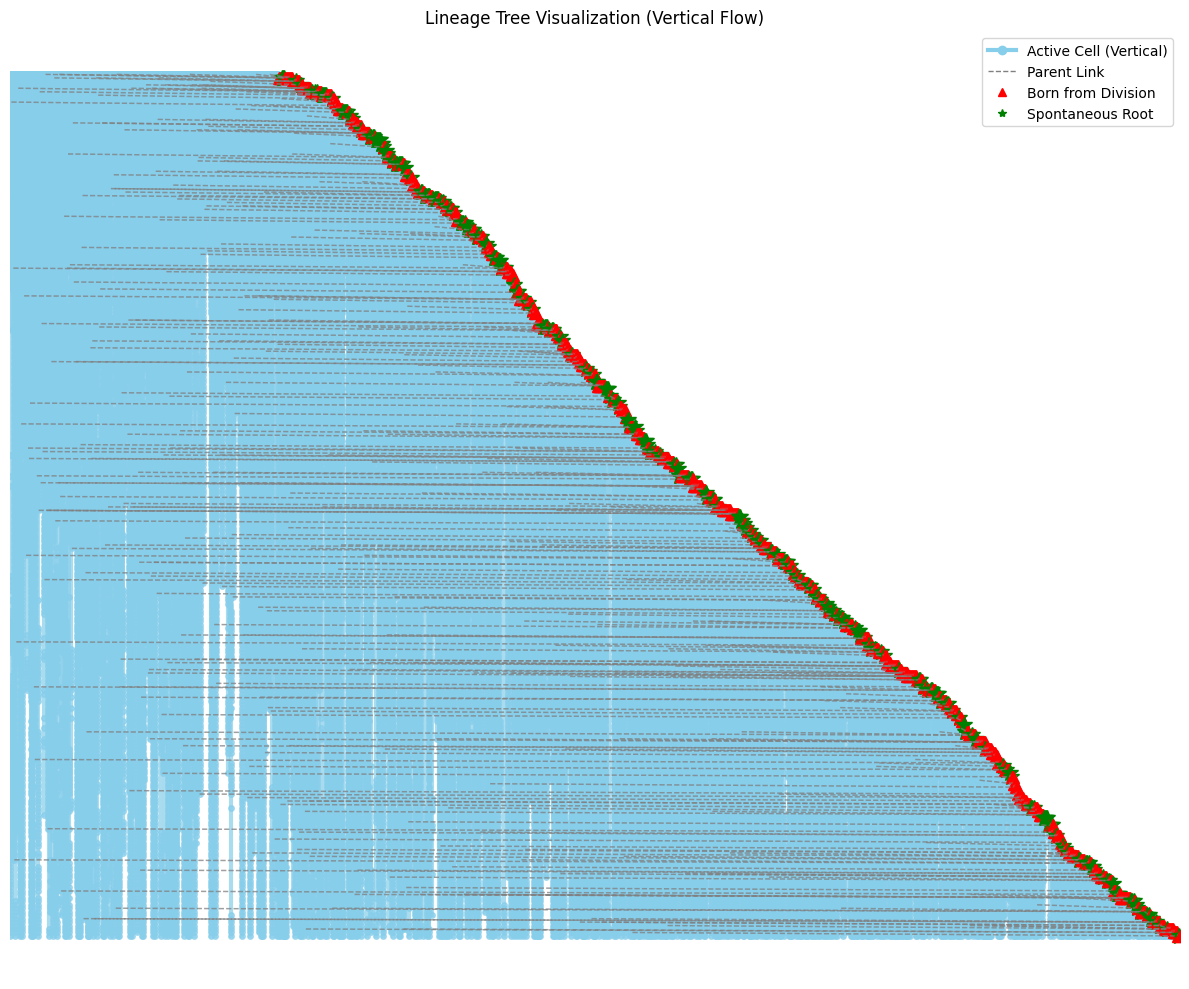

In [ ]:
visualize_caliban_lineage(data)

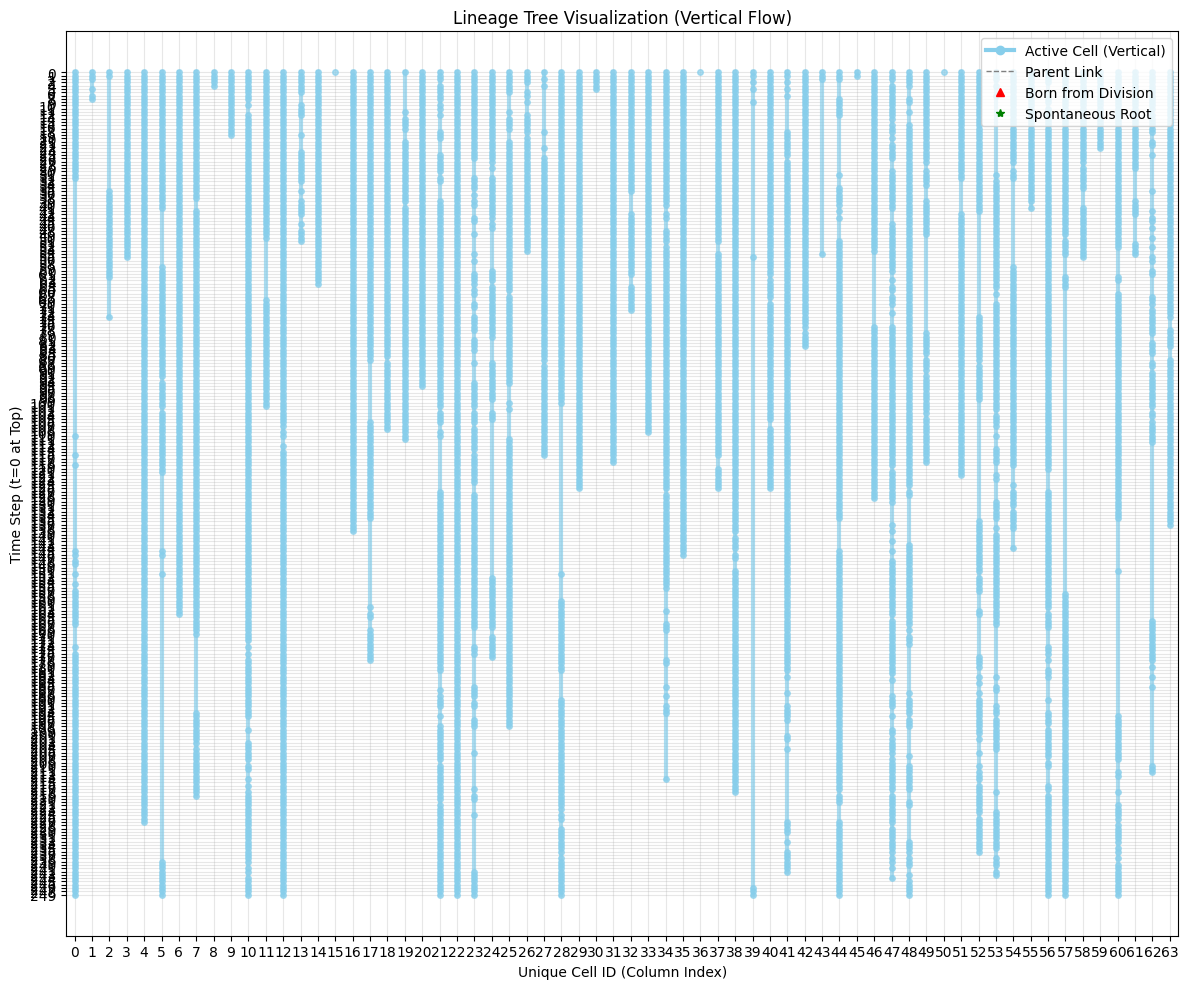

In [96]:
from utils import visualize_lineage
visualize_lineage(data)

#### sanity check for generated data
- parent cell is inactive after division event
- parent index for root cell is itself always
- parent index for daughter cell is always the parent (doesn't switch to daughter after division frame)

In [34]:
division_data

,parent,daughter_1,daughter_2,frame
0,2,336,337,9
1,4,511,513,57
2,5,1103,1108,228
3,7,881,883,165
4,9,309,316,5
...,...,...,...,...
323,1054,1157,1158,241
324,1058,1092,1096,226
325,1089,1152,1154,239
326,1164,1168,1170,243


In [40]:
caliban_tracks.shape, active_mask.shape, parent_indices.shape, is_division_mask.shape, is_new_root_mask.shape

((250, 600, 600), (250, 1200), (250, 1200), (250, 1200), (250, 1200))

In [39]:
parent_idx = id_to_col[2]
daughter_1_idx = id_to_col[336]
daughter_2_idx = id_to_col[337]

In [43]:
# last time where parent is active should be the frame right before division frame
np.max(np.where(caliban_tracks == 2)[0])

np.int64(8)

In [45]:
print(np.max(np.where(active_mask[:, parent_idx])[0]))  # should match above
print(np.min(np.where(active_mask[:, daughter_1_idx])[0]))  # should match division frame
print(np.min(np.where(active_mask[:, daughter_2_idx])[0]))  # should match division

8
9
9


In [50]:
print(parent_id)
parent_indices[:, parent_idx]

1


array([1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0], dtype=int32)

In [51]:
parent_indices[:, daughter_1_idx]

array([  0,   0,   0,   0,   0,   0,   0,   0,   0,   1, 335, 335,   0,
         0,   0,   0,   0,   0, 335,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0, 335, 335, 335, 335, 335, 335, 335, 335,
       335, 335,   0,   0, 335, 335, 335, 335, 335, 335,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0, 335, 335, 335, 335, 335,
       335, 335, 335,   0, 335,   0,   0,   0,   0,   0,   0,   

In [52]:
parent_indices[:, daughter_2_idx]

array([  0,   0,   0,   0,   0,   0,   0,   0,   0,   1, 336, 336, 336,
       336, 336, 336, 336, 336, 336, 336, 336, 336, 336, 336, 336, 336,
       336, 336,   0, 336,   0,   0,   0,   0,   0,   0,   0,   0,   0,
       336,   0,   0,   0,   0,   0, 336, 336, 336, 336, 336, 336, 336,
       336, 336, 336, 336, 336, 336, 336, 336, 336, 336, 336, 336, 336,
       336, 336, 336, 336, 336, 336, 336, 336, 336, 336, 336, 336, 336,
       336, 336, 336, 336, 336, 336, 336, 336, 336, 336, 336, 336, 336,
       336, 336, 336, 336, 336, 336, 336, 336, 336, 336, 336, 336, 336,
       336, 336, 336, 336, 336, 336, 336,   0, 336, 336, 336, 336, 336,
       336, 336, 336, 336, 336, 336, 336, 336, 336, 336, 336, 336, 336,
       336, 336,   0, 336, 336, 336, 336, 336, 336,   0, 336, 336, 336,
       336,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   

In [72]:
print((np.where(active_mask[:, parent_idx])[0] == np.where(parent_indices[:, parent_idx] > 0)[0]).all())
print((np.where(active_mask[:, daughter_1_idx])[0] == np.where(parent_indices[:, daughter_1_idx] > 0)[0]).all())
print((np.where(active_mask[:, daughter_2_idx])[0] == np.where(parent_indices[:, daughter_2_idx] > 0)[0]).all())

True
True
True


In [75]:
print((np.where(active_mask[:, parent_idx])[0] == np.where(is_new_root_mask[:, parent_idx])[0]).all())
print((np.where(active_mask[:, daughter_1_idx])[0] == np.where(is_division_mask[:, daughter_1_idx])[0]).all())
print((np.where(active_mask[:, daughter_2_idx])[0] == np.where(is_division_mask[:, daughter_2_idx])[0]).all())

False
False
False


In [77]:
np.where(is_new_root_mask[:, parent_idx])[0]

array([0])

In [ ]:
print(np.where(is_division_mask[:, daughter_1_idx])[0])

array([9])

In [80]:
print(np.where(is_division_mask[:, daughter_2_idx])[0])

[9]


### Input into model

In [24]:
import sys
import os
import importlib

os.chdir("/gladstone/engelhardt/lab/jutran/lci/treeHMM")

import jax
import jax.numpy as jnp
import jax.random as jr
from jax.scipy.stats import multivariate_normal

from utils import generate_tree_hmm_data
from utils import visualize_lineage

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from dynamax.hidden_markov_model import LinearAutoregressiveHMM
from models.tarhmm import tARHMM
from dynamax.utils.plotting import gradient_cmap
from dynamax.utils.utils import random_rotation
#from dynamax.hidden_markov_model.models.tarhmm import tree_hmm_backward_filter
from typing import Callable, Optional
from dynamax.types import IntScalar, Float, Array

# module import version sanity check
hasattr(jax.interpreters.xla, 'pytype_aval_mappings')


An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


True

In [23]:
num_states = 3
emission_dim = 2
num_lags = 1

In [26]:
rng = np.random.default_rng(seed=42)

emissions = rng.normal(loc=0, scale=1, size=(250, 1200, 2)) 

In [29]:
emissions.shape, is_division_mask.shape, is_new_root_mask.shape, parent_indices.shape, active_mask.shape

((250, 1200, 2), (250, 1200), (250, 1200), (250, 1200), (250, 1200))

In [30]:
arhmm = tARHMM(num_states, emission_dim, num_lags=num_lags)
params, props = arhmm.initialize(key=jr.PRNGKey(1), method="kmeans", emissions=emissions)
inputs = arhmm.compute_inputs(
    jnp.array(emissions),
    jnp.array(parent_indices),
    jnp.array(is_division_mask),
    jnp.array(is_new_root_mask),
    jnp.array(active_mask),
)

In [32]:
batched_emissions = jnp.stack([emissions,emissions])
batched_inputs = jnp.stack([inputs,inputs])
batched_parent_indices = jnp.stack([parent_indices, parent_indices])
batched_is_division_mask = jnp.stack([is_division_mask, is_division_mask])
batched_active_mask = jnp.stack([active_mask, active_mask])
batched_is_new_root_mask = jnp.stack([is_new_root_mask, is_new_root_mask])


In [33]:
fitted_params, lps = arhmm.fit_em(params, props, batched_emissions, inputs=batched_inputs,
    parent_indices=batched_parent_indices,
    is_division_mask=batched_is_division_mask,
    active_mask=batched_active_mask,
    is_new_root_mask=batched_is_new_root_mask)

<div><progress max="50" value="50"></progress> 100.00% [50/50 00:04&lt;00:00]</div>